# Open-BC Choi Transfer Spectrum: Time-Convergence Diagnostics

This notebook analyzes the completed v6 CPU campaign and asks whether the rooted singular-value spectrum converges with cycle number.  The primary object is

$$q_j(C)=s_j(C)^{1/C},$$

loaded from the saved `rooted_singular_values` arrays.  Working with $$q_j(C)$$ keeps endpoint saturation visible without letting raw log-spectrum infinities dominate every convergence metric.


In [1]:
# CPU allocation controls. Edit CPU_LIST before executing interactively.
import os

CPU_LIST = None  # e.g. "0-15" or None to keep current affinity

def parse_cpu_list(spec):
    if spec is None:
        return None
    cpus = []
    for part in str(spec).split(','):
        part = part.strip()
        if not part:
            continue
        if '-' in part:
            start, stop = [int(x) for x in part.split('-', 1)]
            cpus.extend(range(start, stop + 1))
        else:
            cpus.append(int(part))
    return sorted(set(cpus))

_requested = parse_cpu_list(CPU_LIST)
if _requested is not None and hasattr(os, 'sched_setaffinity'):
    os.sched_setaffinity(0, _requested)
print('effective CPU affinity:', sorted(os.sched_getaffinity(0)) if hasattr(os, 'sched_getaffinity') else 'unavailable')


effective CPU affinity: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111]


## Imports And Campaign Paths

The notebook reads only lightweight spectrum/diagnostic files by default.  It does not load the full dense transfer-matrix arrays, which are large for `Nx=24`.


In [2]:
from __future__ import annotations

from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

REPO_ROOT = Path('/home/abhuiyan/class_A_fermionic_adaptive_circuit')
CAMPAIGN_ROOT = REPO_ROOT / 'choi_covariance_cpu/cpu_data/complex_particle_choi_transfer/campaigns/Nx16-20-24_Ny20_DW1_dwtrunc1_openBC_transfer_a1-1-3x21_S10_C40_v6'
FIG_DIR = REPO_ROOT / 'choi_covariance_cpu/figures/openbc_transfer_v6'
FIG_DIR.mkdir(parents=True, exist_ok=True)

REP_ALPHAS = [1.0, 1.8, 2.0, 2.1, 2.5, 3.0]
NX_VALUES = [16, 20, 24]
QGRID = np.linspace(0.0, 1.0, 101)
DPI = 300

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['CMU Sans Serif', 'DejaVu Sans'],
    'mathtext.fontset': 'cm',
    'figure.dpi': DPI,
    'savefig.dpi': DPI,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6,
    'lines.linewidth': 1.2,
})

manifest = json.loads((CAMPAIGN_ROOT / 'campaign_manifest.json').read_text())
assert manifest['status'] == 'completed'
print('campaign:', manifest['campaign_id'])
print('configs:', len(manifest['results']))
print('transfer matrices saved:', manifest.get('transfer_matrix_saved_by_cycle'))


campaign: Nx16-20-24_Ny20_DW1_dwtrunc1_openBC_transfer_a1-1-3x21_S10_C40_v6
configs: 63
transfer matrices saved: True


## Load Rooted Spectra And Summary Tables

Each run contributes `rooted_singular_values`, finite-sector counts, gap arrays, and transfer-matrix validity diagnostics.  Full `transfer_matrix` arrays are intentionally skipped.


In [3]:
def alpha_label(alpha: float) -> str:
    return f'{float(alpha):.1f}'.rstrip('0').rstrip('.')

records = []
run_data = {}

for row in manifest['results']:
    nx = int(row['Nx'])
    alpha = float(row['alpha_1'])
    run_dir = Path(row['output_dir'])
    with np.load(run_dir / 'particle_choi_transfer_spectrum_vs_cycle.npz', allow_pickle=False) as spec:
        cycles = spec['cycles'].astype(int)
        q = spec['rooted_singular_values'].astype(float)
        finite_counts = spec['finite_exponent_count'].astype(int)
        stable = spec['stable_at_cycle'].astype(bool)
    with np.load(run_dir / 'particle_choi_transfer_gap_vs_cycle.npz', allow_pickle=False) as gap_file:
        gap = gap_file['gap'].astype(float)
        no_finite = gap_file['no_finite_exponents'].astype(bool)
    with np.load(run_dir / 'particle_choi_transfer_matrix_vs_cycle.npz', allow_pickle=False) as tm:
        transfer_valid = tm['transfer_matrix_valid'].astype(bool)
        transfer_max_abs = tm['transfer_matrix_max_abs'].astype(float)

    run_data[(nx, alpha)] = {
        'cycles': cycles,
        'q': q,
        'finite_counts': finite_counts,
        'stable': stable,
        'gap': gap,
        'no_finite': no_finite,
        'transfer_valid': transfer_valid,
        'transfer_max_abs': transfer_max_abs,
    }

    final_gap = gap[:, -1]
    finite_final = np.isfinite(final_gap)
    first_zero = []
    for sample_idx in range(no_finite.shape[0]):
        idx = np.where(no_finite[sample_idx])[0]
        first_zero.append(int(cycles[idx[0]]) if idx.size else np.nan)

    records.append({
        'Nx': nx,
        'alpha_1': alpha,
        'stable_final_samples': int(stable[:, -1].sum()),
        'final_finite_samples': int(finite_final.sum()),
        'final_rms_gap_finite': float(np.sqrt(np.nanmean(final_gap[finite_final]**2))) if finite_final.any() else np.nan,
        'all_cycle_rms_gap_finite': float(np.sqrt(np.nanmean(gap[np.isfinite(gap)]**2))) if np.isfinite(gap).any() else np.nan,
        'final_finite_count_median': float(np.median(finite_counts[:, -1])),
        'median_first_zero_cycle': float(np.nanmedian(first_zero)) if np.isfinite(first_zero).any() else np.nan,
        'transfer_valid_fraction': float(transfer_valid.mean()),
        'max_abs_transfer': float(np.nanmax(transfer_max_abs)) if np.isfinite(transfer_max_abs).any() else np.nan,
    })

summary_df = pd.DataFrame.from_records(records).sort_values(['Nx', 'alpha_1']).reset_index(drop=True)
summary_df.head()


,Nx,alpha_1,stable_final_samples,final_finite_samples,final_rms_gap_finite,all_cycle_rms_gap_finite,final_finite_count_median,median_first_zero_cycle,transfer_valid_fraction,max_abs_transfer
0,16,1.0,10,10,0.058685,0.028970,8.0,NaN,1.0,1.051875e+08
1,16,1.1,10,10,0.057140,0.035702,8.0,NaN,1.0,1.140251e+08
2,16,1.2,10,10,0.014010,0.037909,8.0,NaN,1.0,1.894669e+08
3,16,1.3,10,10,0.022108,0.041514,8.0,NaN,1.0,3.301149e+08
4,16,1.4,10,10,0.074619,0.041299,9.0,NaN,1.0,2.135137e+08


## Gap Dependence On $$\alpha_1$$

This section summarizes the final-cycle transfer gap across the open-boundary alpha sweep.  The finite-only RMS gap uses only samples with a finite nonendpoint final gap.  The sentinel RMS gap replaces undefined final gaps by `10.0`, making endpoint-saturated configurations visible as a high plateau rather than missing data.


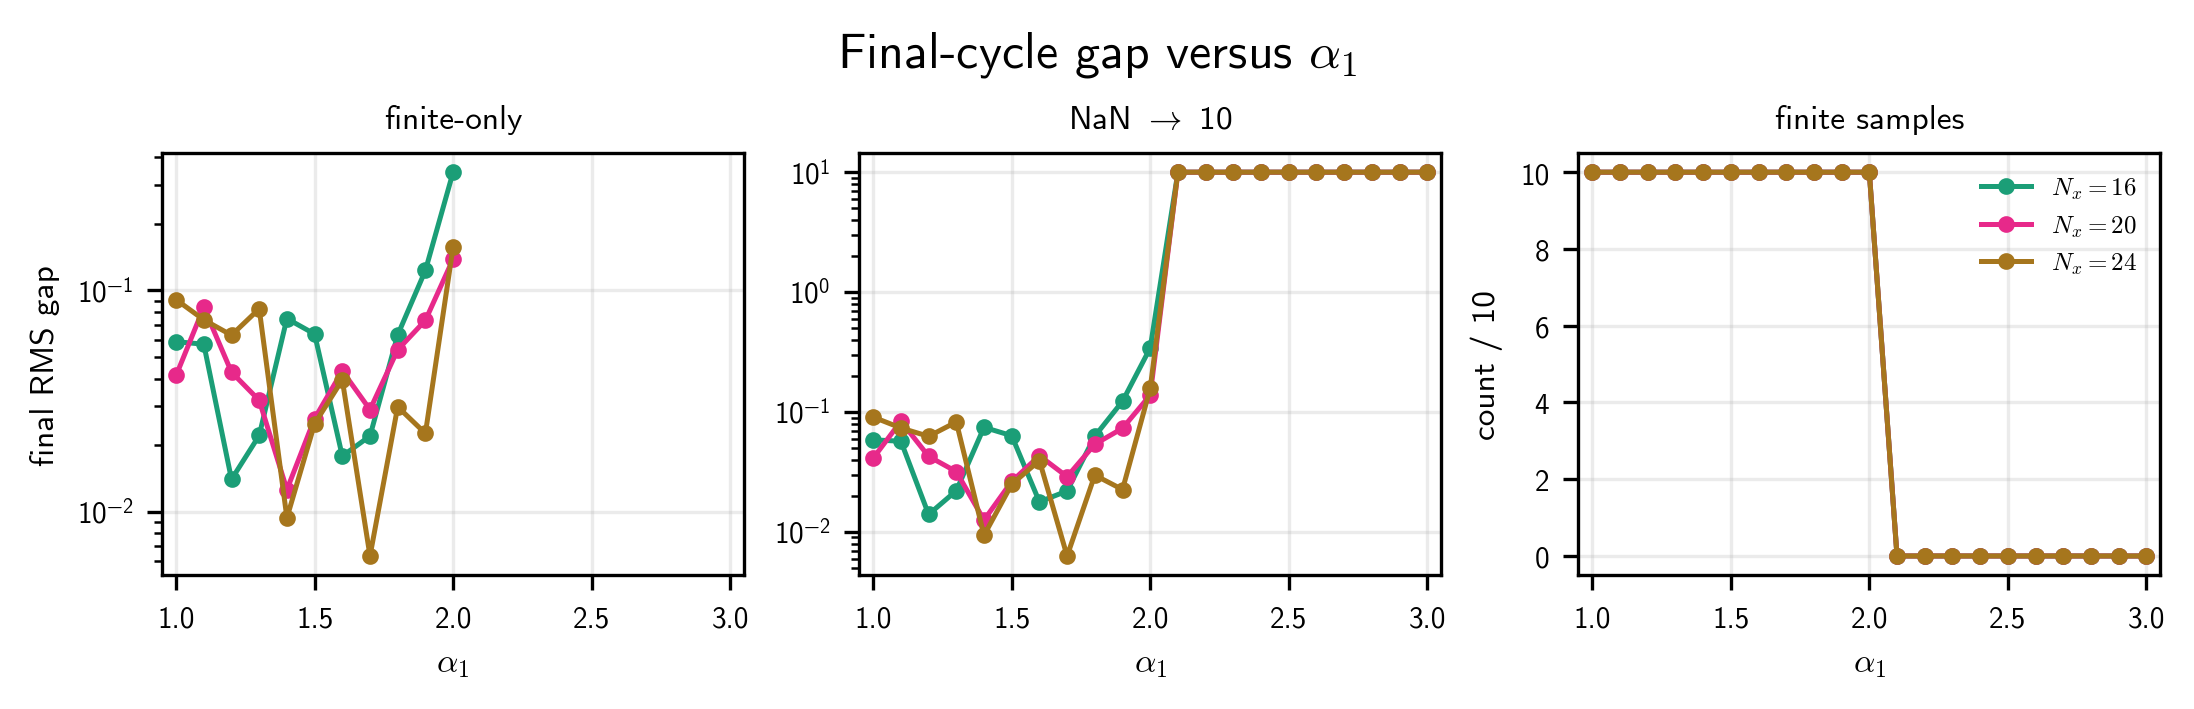

,Nx,alpha_1,finite_samples,finite_only_final_rms_gap,sentinel_final_rms_gap,median_final_finite_support
0,16,1.0,10,0.058685,0.058685,8.0
1,16,1.1,10,0.057140,0.057140,8.0
2,16,1.2,10,0.014010,0.014010,8.0
3,16,1.3,10,0.022108,0.022108,8.0
4,16,1.4,10,0.074619,0.074619,9.0
...,...,...,...,...,...,...
58,24,2.6,0,NaN,10.000000,0.0
59,24,2.7,0,NaN,10.000000,0.0
60,24,2.8,0,NaN,10.000000,0.0
61,24,2.9,0,NaN,10.000000,0.0


In [4]:
GAP_NAN_SENTINEL = 10.0

fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.25), constrained_layout=True)
colors = dict(zip(NX_VALUES, plt.cm.Dark2(np.linspace(0.05, 0.75, len(NX_VALUES)))))

for nx in NX_VALUES:
    df = summary_df[summary_df['Nx'] == nx].sort_values('alpha_1')
    axes[0].plot(df['alpha_1'], df['final_rms_gap_finite'], marker='o', ms=3, color=colors[nx], label=fr'$N_x={nx}$')

    sentinel_rms = []
    finite_counts = []
    alphas = []
    for alpha in df['alpha_1']:
        gap = run_data[(nx, float(alpha))]['gap'][:, -1]
        gap_plot = np.where(np.isfinite(gap), gap, GAP_NAN_SENTINEL)
        sentinel_rms.append(float(np.sqrt(np.mean(gap_plot**2))))
        finite_counts.append(int(np.count_nonzero(np.isfinite(gap))))
        alphas.append(float(alpha))
    axes[1].plot(alphas, sentinel_rms, marker='o', ms=3, color=colors[nx], label=fr'$N_x={nx}$')
    axes[2].plot(alphas, finite_counts, marker='o', ms=3, color=colors[nx], label=fr'$N_x={nx}$')

axes[0].set_title('finite-only')
axes[0].set_ylabel(r'final RMS gap')
axes[0].set_yscale('log')
axes[1].set_title(fr'NaN $\to$ {GAP_NAN_SENTINEL:g}')
axes[1].set_yscale('log')
axes[2].set_title('finite samples')
axes[2].set_ylabel('count / 10')
axes[2].set_ylim(-0.5, 10.5)

for ax in axes:
    ax.set_xlabel(r'$\alpha_1$')
    ax.grid(True, alpha=0.25)
    ax.set_xlim(0.95, 3.05)
axes[2].legend(frameon=False, loc='best')
fig.suptitle(r'Final-cycle gap versus $\alpha_1$')
for ext in ('png', 'pdf'):
    fig.savefig(FIG_DIR / f'final_gap_vs_alpha_openbc_v6.{ext}', bbox_inches='tight')
plt.show()

gap_alpha_summary = []
for nx in NX_VALUES:
    for alpha in sorted(summary_df[summary_df['Nx'] == nx]['alpha_1']):
        data = run_data[(nx, float(alpha))]
        gap_final = data['gap'][:, -1]
        gap_plot = np.where(np.isfinite(gap_final), gap_final, GAP_NAN_SENTINEL)
        gap_alpha_summary.append({
            'Nx': nx,
            'alpha_1': float(alpha),
            'finite_samples': int(np.count_nonzero(np.isfinite(gap_final))),
            'finite_only_final_rms_gap': float(np.sqrt(np.nanmean(gap_final[np.isfinite(gap_final)]**2))) if np.isfinite(gap_final).any() else np.nan,
            'sentinel_final_rms_gap': float(np.sqrt(np.mean(gap_plot**2))),
            'median_final_finite_support': float(np.median(data['finite_counts'][:, -1])),
        })
gap_alpha_df = pd.DataFrame(gap_alpha_summary)
gap_alpha_df


### Gap-Alpha Summary

The finite-only gap shows the nonendpoint transfer sector where it exists.  The sentinel panel is a visualization convention: the sharp jump above $$\alpha_1\simeq 2$$ means the final finite sector is absent, not that a large finite gap was directly measured.


## Spectrum-Time Convergence Metrics

For each sample and adjacent cycle pair, the rooted spectra are sorted before comparison.  The max and RMS changes are index-wise distances on the sorted finite nonnegative rooted values.  The quantile distance compares interpolated empirical spectra and is less sensitive to changes in the number of available finite values.


In [5]:
def finite_nonnegative_values(values: np.ndarray) -> np.ndarray:
    arr = np.asarray(values, dtype=float).reshape(-1)
    mask = np.isfinite(arr) & (arr >= 0.0)
    return np.sort(arr[mask])


def interp_quantiles(values: np.ndarray, grid: np.ndarray = QGRID) -> np.ndarray | None:
    vals = finite_nonnegative_values(values)
    if vals.size == 0:
        return None
    if vals.size == 1:
        return np.full_like(grid, vals[0], dtype=float)
    src = np.linspace(0.0, 1.0, vals.size)
    return np.interp(grid, src, vals)


def cycle_change_metrics(q: np.ndarray) -> dict[str, np.ndarray]:
    samples, ncycles, _ = q.shape
    max_change = np.full((samples, ncycles - 1), np.nan, dtype=float)
    rms_change = np.full_like(max_change, np.nan)
    quantile_distance = np.full_like(max_change, np.nan)
    comparable_count = np.zeros((samples, ncycles - 1), dtype=int)

    for s in range(samples):
        for c in range(1, ncycles):
            prev = finite_nonnegative_values(q[s, c - 1])
            curr = finite_nonnegative_values(q[s, c])
            n = min(prev.size, curr.size)
            comparable_count[s, c - 1] = n
            if n > 0:
                delta = curr[:n] - prev[:n]
                max_change[s, c - 1] = np.max(np.abs(delta))
                rms_change[s, c - 1] = np.sqrt(np.mean(delta**2))
            prev_q = interp_quantiles(q[s, c - 1])
            curr_q = interp_quantiles(q[s, c])
            if prev_q is not None and curr_q is not None:
                quantile_distance[s, c - 1] = np.sqrt(np.mean((curr_q - prev_q)**2))
    return {
        'max_change': max_change,
        'rms_change': rms_change,
        'quantile_distance': quantile_distance,
        'comparable_count': comparable_count,
    }


def nan_quantiles(arr: np.ndarray, qs=(0.25, 0.5, 0.75), axis=0) -> tuple[np.ndarray, ...]:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        return tuple(np.nanquantile(arr, q, axis=axis) for q in qs)

for key, data in run_data.items():
    data.update(cycle_change_metrics(data['q']))

print('computed convergence metrics for', len(run_data), 'runs')


computed convergence metrics for 63 runs


## Max Cycle-To-Cycle Change

This is the strictest convergence diagnostic: a single mobile singular value can keep the curve high.  Decay toward zero indicates that the rooted spectrum is becoming cycle-stationary; a sudden drop can also signal endpoint collapse.


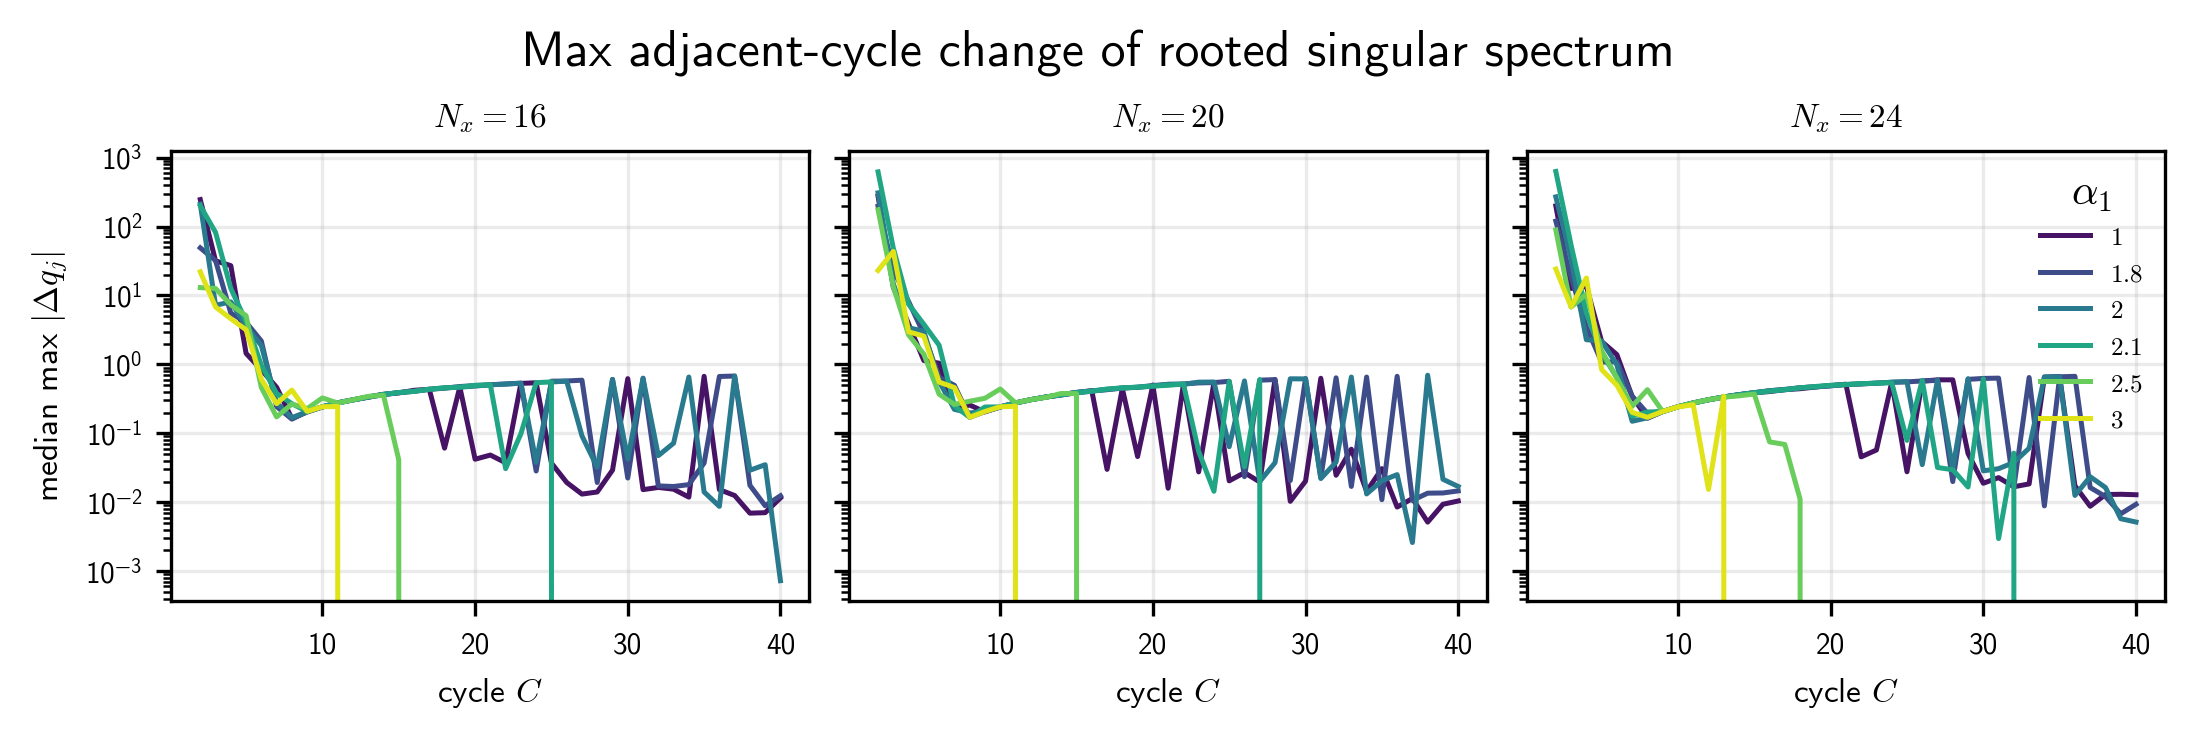

,Nx,alpha_1,final_cycle_median_max_change
0,16,1.0,0.011566
1,16,1.8,0.012417
2,16,2.0,0.000727
3,16,2.1,0.000000
4,16,2.5,0.000000
5,16,3.0,0.000000
6,20,1.0,0.010433
7,20,1.8,0.014605
8,20,2.0,0.016933
9,20,2.1,0.000000


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.35), sharey=True, constrained_layout=True)
colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(REP_ALPHAS)))
for ax, nx in zip(axes, NX_VALUES):
    for color, alpha in zip(colors, REP_ALPHAS):
        data = run_data[(nx, alpha)]
        x = data['cycles'][1:]
        lo, med, hi = nan_quantiles(data['max_change'])
        ax.plot(x, med, color=color, label=fr'${alpha:g}$')
        ax.fill_between(x, lo, hi, color=color, alpha=0.18, linewidth=0)
    ax.set_title(fr'$N_x={nx}$')
    ax.set_xlabel('cycle $C$')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.25)
axes[0].set_ylabel(r'median max $|\Delta q_j|$')
axes[-1].legend(title=r'$\alpha_1$', frameon=False, ncols=1, loc='upper right')
fig.suptitle(r'Max adjacent-cycle change of rooted singular spectrum')
for ext in ('png', 'pdf'):
    fig.savefig(FIG_DIR / f'spectrum_cycle_to_cycle_max_change.{ext}', bbox_inches='tight')
plt.show()

rows = []
for nx in NX_VALUES:
    for alpha in REP_ALPHAS:
        med_final = float(np.nanmedian(run_data[(nx, alpha)]['max_change'][:, -1]))
        rows.append({'Nx': nx, 'alpha_1': alpha, 'final_cycle_median_max_change': med_final})
pd.DataFrame(rows)


## RMS Cycle-To-Cycle Change

The RMS version measures typical motion across the sorted rooted spectrum.  It is less dominated by one outlier mode and is useful for deciding whether the bulk of the spectrum has settled.


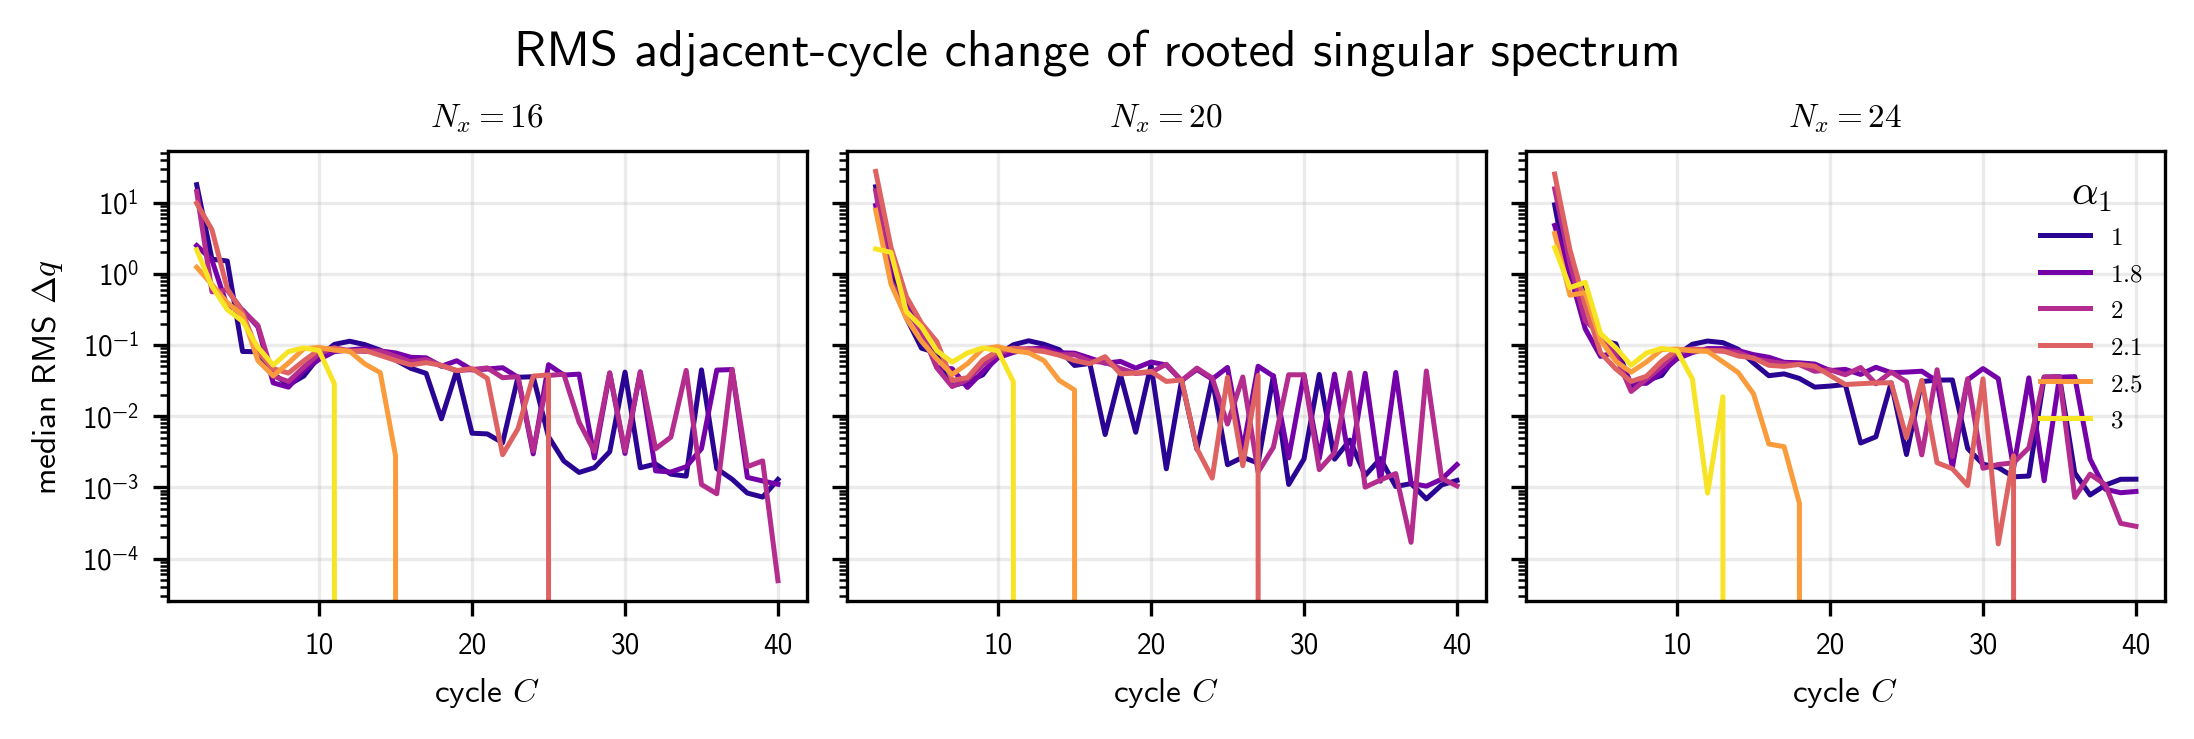

,Nx,alpha_1,final_cycle_median_rms_change
0,16,1.0,0.001294
1,16,1.8,0.001107
2,16,2.0,0.000049
3,16,2.1,0.000000
4,16,2.5,0.000000
5,16,3.0,0.000000
6,20,1.0,0.001253
7,20,1.8,0.002088
8,20,2.0,0.001050
9,20,2.1,0.000000


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.35), sharey=True, constrained_layout=True)
colors = plt.cm.plasma(np.linspace(0.05, 0.95, len(REP_ALPHAS)))
for ax, nx in zip(axes, NX_VALUES):
    for color, alpha in zip(colors, REP_ALPHAS):
        data = run_data[(nx, alpha)]
        x = data['cycles'][1:]
        lo, med, hi = nan_quantiles(data['rms_change'])
        ax.plot(x, med, color=color, label=fr'${alpha:g}$')
        ax.fill_between(x, lo, hi, color=color, alpha=0.18, linewidth=0)
    ax.set_title(fr'$N_x={nx}$')
    ax.set_xlabel('cycle $C$')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.25)
axes[0].set_ylabel(r'median RMS $\Delta q$')
axes[-1].legend(title=r'$\alpha_1$', frameon=False, ncols=1, loc='upper right')
fig.suptitle(r'RMS adjacent-cycle change of rooted singular spectrum')
for ext in ('png', 'pdf'):
    fig.savefig(FIG_DIR / f'spectrum_cycle_to_cycle_rms_change.{ext}', bbox_inches='tight')
plt.show()

rows = []
for nx in NX_VALUES:
    for alpha in REP_ALPHAS:
        med_final = float(np.nanmedian(run_data[(nx, alpha)]['rms_change'][:, -1]))
        rows.append({'Nx': nx, 'alpha_1': alpha, 'final_cycle_median_rms_change': med_final})
pd.DataFrame(rows)


## Distribution/Quantile Spectral Distance

This treats each rooted spectrum as an empirical distribution and compares adjacent cycles on a fixed quantile grid.  It is the most stable diagnostic when the apparent finite sector changes size or when neighboring singular values exchange order.


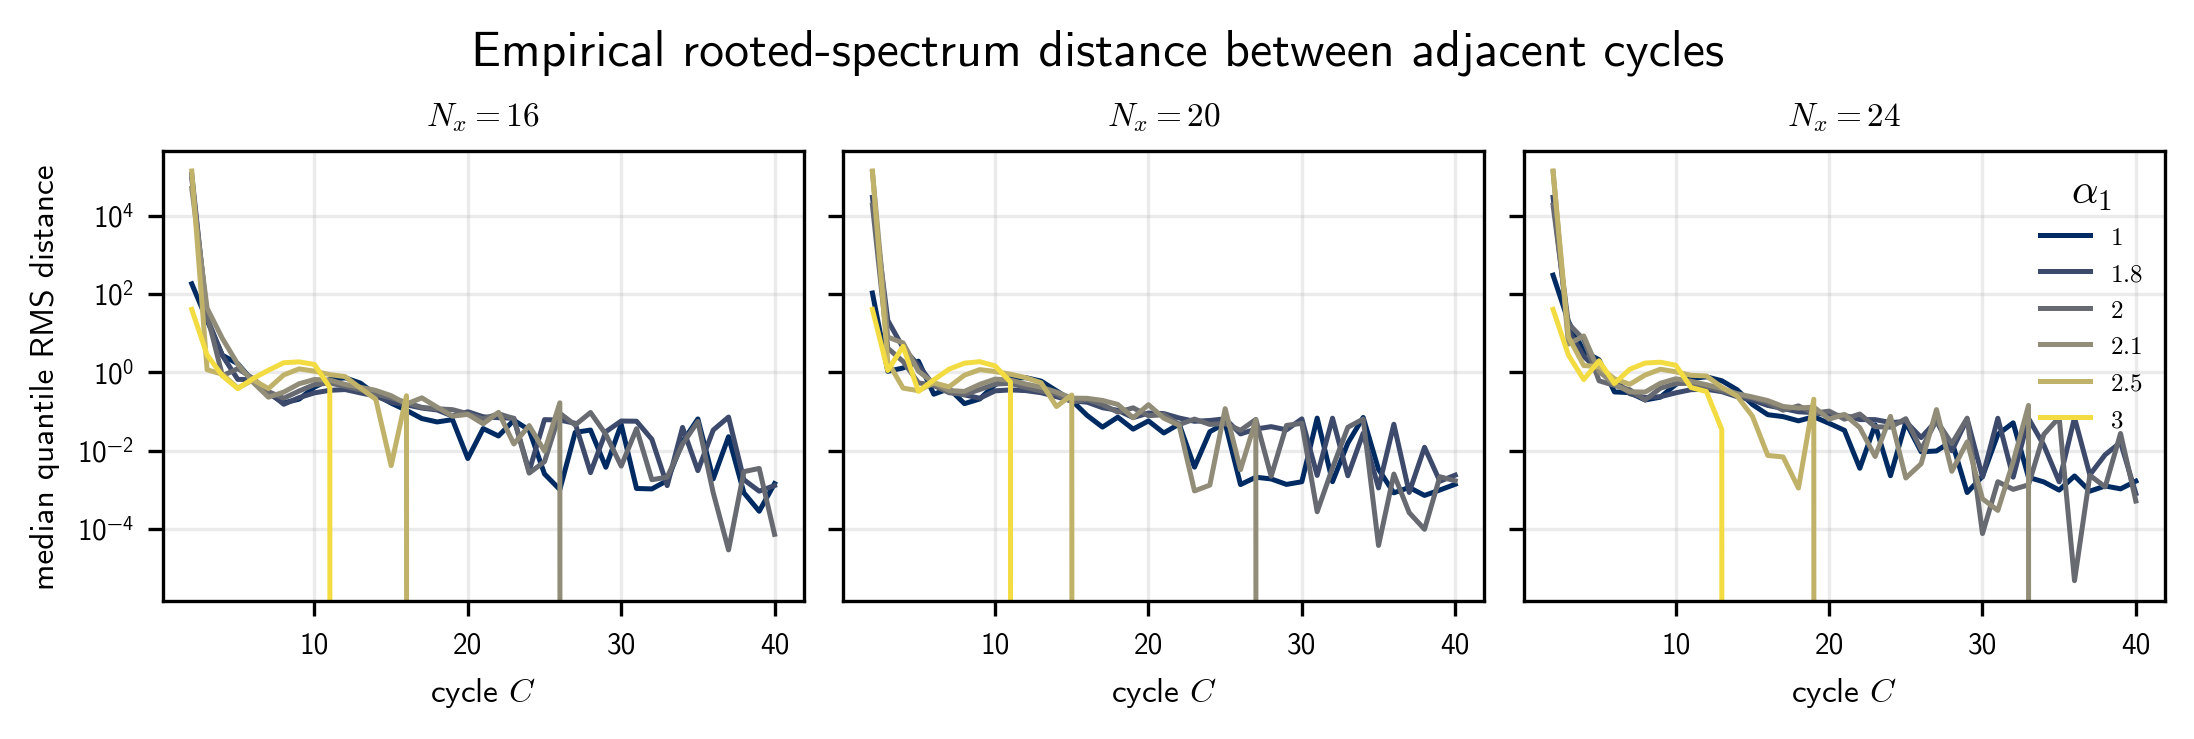

,Nx,alpha_1,final_cycle_median_quantile_distance
0,16,1.0,0.001428
1,16,1.8,0.001276
2,16,2.0,0.000072
3,16,2.1,0.000000
4,16,2.5,0.000000
5,16,3.0,0.000000
6,20,1.0,0.001376
7,20,1.8,0.002352
8,20,2.0,0.001685
9,20,2.1,0.000000


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.35), sharey=True, constrained_layout=True)
colors = plt.cm.cividis(np.linspace(0.05, 0.95, len(REP_ALPHAS)))
for ax, nx in zip(axes, NX_VALUES):
    for color, alpha in zip(colors, REP_ALPHAS):
        data = run_data[(nx, alpha)]
        x = data['cycles'][1:]
        lo, med, hi = nan_quantiles(data['quantile_distance'])
        ax.plot(x, med, color=color, label=fr'${alpha:g}$')
        ax.fill_between(x, lo, hi, color=color, alpha=0.18, linewidth=0)
    ax.set_title(fr'$N_x={nx}$')
    ax.set_xlabel('cycle $C$')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.25)
axes[0].set_ylabel(r'median quantile RMS distance')
axes[-1].legend(title=r'$\alpha_1$', frameon=False, ncols=1, loc='upper right')
fig.suptitle(r'Empirical rooted-spectrum distance between adjacent cycles')
for ext in ('png', 'pdf'):
    fig.savefig(FIG_DIR / f'spectrum_cycle_to_cycle_quantile_distance.{ext}', bbox_inches='tight')
plt.show()

rows = []
for nx in NX_VALUES:
    for alpha in REP_ALPHAS:
        med_final = float(np.nanmedian(run_data[(nx, alpha)]['quantile_distance'][:, -1]))
        rows.append({'Nx': nx, 'alpha_1': alpha, 'final_cycle_median_quantile_distance': med_final})
pd.DataFrame(rows)


## Finite Spectral Support Size

The finite support count separates two possibilities: a spectrum can appear time-stationary because a nontrivial finite sector has converged, or because the nonendpoint sector has collapsed and all remaining singular values sit at endpoints.


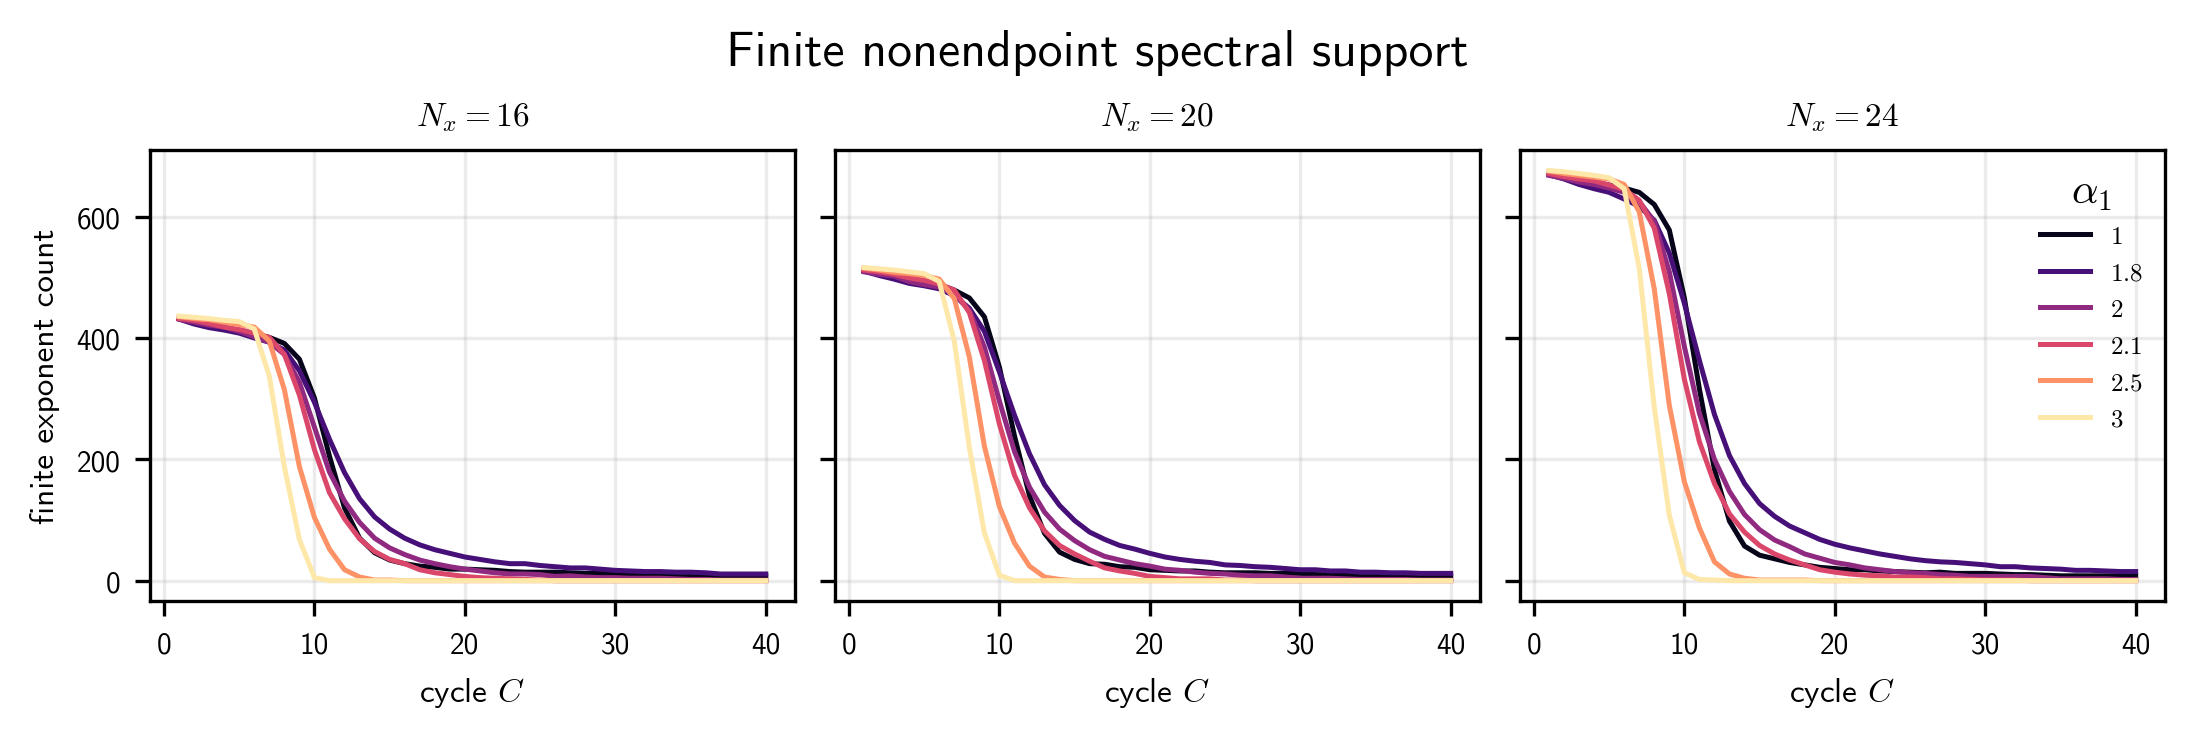

,Nx,alpha_1,initial_median_support,final_median_support,min_final_support,max_final_support
0,16,1.0,432.0,8.0,8,8
1,16,1.8,431.0,11.0,11,11
2,16,2.0,431.0,1.0,1,1
3,16,2.1,432.0,0.0,0,0
4,16,2.5,435.0,0.0,0,0
5,16,3.0,436.0,0.0,0,0
6,20,1.0,512.0,8.0,8,8
7,20,1.8,510.0,12.0,12,12
8,20,2.0,509.0,1.0,1,1
9,20,2.1,512.0,0.0,0,0


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.35), sharey=True, constrained_layout=True)
colors = plt.cm.magma(np.linspace(0.05, 0.95, len(REP_ALPHAS)))
for ax, nx in zip(axes, NX_VALUES):
    for color, alpha in zip(colors, REP_ALPHAS):
        data = run_data[(nx, alpha)]
        x = data['cycles']
        lo, med, hi = nan_quantiles(data['finite_counts'])
        ax.plot(x, med, color=color, label=fr'${alpha:g}$')
        ax.fill_between(x, lo, hi, color=color, alpha=0.18, linewidth=0)
    ax.set_title(fr'$N_x={nx}$')
    ax.set_xlabel('cycle $C$')
    ax.grid(True, alpha=0.25)
axes[0].set_ylabel('finite exponent count')
axes[-1].legend(title=r'$\alpha_1$', frameon=False, ncols=1, loc='upper right')
fig.suptitle(r'Finite nonendpoint spectral support')
for ext in ('png', 'pdf'):
    fig.savefig(FIG_DIR / f'finite_spectral_support_vs_cycle.{ext}', bbox_inches='tight')
plt.show()

support_rows = []
for nx in NX_VALUES:
    for alpha in REP_ALPHAS:
        counts = run_data[(nx, alpha)]['finite_counts']
        support_rows.append({
            'Nx': nx,
            'alpha_1': alpha,
            'initial_median_support': float(np.median(counts[:, 0])),
            'final_median_support': float(np.median(counts[:, -1])),
            'min_final_support': int(np.min(counts[:, -1])),
            'max_final_support': int(np.max(counts[:, -1])),
        })
pd.DataFrame(support_rows)


## Final Summary Table

This table combines final finite-sector gap statistics, endpoint-collapse timing, and the transfer-matrix validity summary.  It is useful for interpreting the convergence plots without loading the full matrices.


In [10]:
summary_cols = [
    'Nx', 'alpha_1', 'stable_final_samples', 'final_finite_samples',
    'final_rms_gap_finite', 'all_cycle_rms_gap_finite',
    'final_finite_count_median', 'median_first_zero_cycle',
    'transfer_valid_fraction', 'max_abs_transfer',
]
summary_df[summary_cols]


,Nx,alpha_1,stable_final_samples,final_finite_samples,final_rms_gap_finite,all_cycle_rms_gap_finite,final_finite_count_median,median_first_zero_cycle,transfer_valid_fraction,max_abs_transfer
0,16,1.0,10,10,0.058685,0.028970,8.0,NaN,1.0,1.051875e+08
1,16,1.1,10,10,0.057140,0.035702,8.0,NaN,1.0,1.140251e+08
2,16,1.2,10,10,0.014010,0.037909,8.0,NaN,1.0,1.894669e+08
3,16,1.3,10,10,0.022108,0.041514,8.0,NaN,1.0,3.301149e+08
4,16,1.4,10,10,0.074619,0.041299,9.0,NaN,1.0,2.135137e+08
...,...,...,...,...,...,...,...,...,...,...
58,24,2.6,10,0,NaN,0.692600,0.0,16.0,1.0,3.127668e+08
59,24,2.7,10,0,NaN,0.818547,0.0,15.0,1.0,3.698147e+08
60,24,2.8,10,0,NaN,0.865155,0.0,14.0,1.0,5.588161e+08
61,24,2.9,10,0,NaN,0.957625,0.0,14.0,1.0,3.549346e+08


## Short Interpretation

The convergence metrics should be read together with finite support.  Small adjacent-cycle spectral motion at large $$\alpha_1$$ is not automatically evidence for a robust nontrivial transfer spectrum; if the finite support simultaneously goes to zero, the spectrum has become stationary through endpoint saturation.  Conversely, at smaller $$\alpha_1$$, nonzero final support together with decaying max/RMS/quantile distances is evidence that the nonendpoint rooted spectrum is approaching a stable finite-sector object.


## Lyapunov Spectrum Histogram Movie

The saved `spectrum` array is the cycle-normalized log-singular-value spectrum.  The animation below shows the distribution of this Lyapunov spectrum as a function of cycle.  Each frame pools the 10 samples for a fixed `(Nx, alpha_1)` and plots the fraction of spectral entries in each bin.  For display, `NaN` and `+inf` are mapped to `+10`, while `-inf` is mapped to `-10`; values outside `[-10,10]` are clipped to the boundary bins.


In [11]:
from matplotlib.backends.backend_agg import FigureCanvasAgg
import imageio.v2 as imageio

MOVIE_ALPHAS = [1.0, 3.0]
LYAP_SENTINEL = 10.0
LYAP_BINS = np.linspace(-10.0, 10.0, 81)
LYAP_FRAME_DURATION_S = 0.28
GIF_PATH = FIG_DIR / 'lyapunov_spectrum_histogram_vs_cycle_alpha1_alpha3.gif'
MP4_PATH = FIG_DIR / 'lyapunov_spectrum_histogram_vs_cycle_alpha1_alpha3.mp4'

# Load only the log spectra needed for this movie.
movie_spectra = {}
for row in manifest['results']:
    nx = int(row['Nx'])
    alpha = float(row['alpha_1'])
    if nx not in NX_VALUES or alpha not in MOVIE_ALPHAS:
        continue
    run_dir = Path(row['output_dir'])
    with np.load(run_dir / 'particle_choi_transfer_spectrum_vs_cycle.npz', allow_pickle=False) as spec:
        movie_spectra[(nx, alpha)] = {
            'cycles': spec['cycles'].astype(int),
            'spectrum': spec['spectrum'].astype(float),
        }

cycles = movie_spectra[(NX_VALUES[0], MOVIE_ALPHAS[0])]['cycles']
frames = []

for cycle_idx, cycle in enumerate(cycles):
    fig, axes = plt.subplots(
        len(NX_VALUES),
        len(MOVIE_ALPHAS),
        figsize=(6.8, 6.0),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    for row_idx, nx in enumerate(NX_VALUES):
        for col_idx, alpha in enumerate(MOVIE_ALPHAS):
            ax = axes[row_idx, col_idx]
            spectrum = movie_spectra[(nx, alpha)]['spectrum'][:, cycle_idx, :].reshape(-1)
            display = np.nan_to_num(
                spectrum,
                nan=LYAP_SENTINEL,
                posinf=LYAP_SENTINEL,
                neginf=-LYAP_SENTINEL,
            )
            display = np.clip(display, -LYAP_SENTINEL, LYAP_SENTINEL)
            weights = np.full(display.shape, 1.0 / max(1, display.size), dtype=float)
            ax.hist(display, bins=LYAP_BINS, weights=weights, color='#356d9a', alpha=0.82, edgecolor='none')
            ax.axvline(0.0, color='black', lw=0.7, alpha=0.55)
            ax.set_yscale('log')
            ax.set_ylim(1e-4, 1.0)
            ax.grid(True, alpha=0.18)
            if row_idx == 0:
                ax.set_title(fr'$\alpha_1={alpha:g}$')
            if col_idx == 0:
                ax.set_ylabel(fr'$N_x={nx}$' + '\nfraction')
            if row_idx == len(NX_VALUES) - 1:
                ax.set_xlabel(r'log singular value / cycle')
    fig.suptitle(
        fr'Lyapunov spectrum distribution, cycle $C={int(cycle)}$'
        + r'  $(\mathrm{NaN},+\infty\to 10;\ -\infty\to -10)$',
        fontsize=10,
    )
    canvas = FigureCanvasAgg(fig)
    canvas.draw()
    rgba = np.asarray(canvas.buffer_rgba())
    frames.append(rgba[:, :, :3].copy())
    plt.close(fig)

imageio.mimsave(GIF_PATH, frames, duration=LYAP_FRAME_DURATION_S, loop=0)
imageio.mimsave(MP4_PATH, frames, fps=1.0 / LYAP_FRAME_DURATION_S, codec='libx264', quality=8, macro_block_size=2)
print('wrote', GIF_PATH)
print('wrote', MP4_PATH)
print('frames:', len(frames), 'one frame per saved cycle:', len(frames) == len(cycles), 'duration_s:', len(frames) * LYAP_FRAME_DURATION_S)
MP4_PATH


[rawvideo @ 0x109ea100] Stream #0: not enough frames to estimate rate; consider increasing probesize


wrote /home/abhuiyan/class_A_fermionic_adaptive_circuit/choi_covariance_cpu/figures/openbc_transfer_v6/lyapunov_spectrum_histogram_vs_cycle_alpha1_alpha3.gif
wrote /home/abhuiyan/class_A_fermionic_adaptive_circuit/choi_covariance_cpu/figures/openbc_transfer_v6/lyapunov_spectrum_histogram_vs_cycle_alpha1_alpha3.mp4
frames: 40 one frame per saved cycle: True duration_s: 11.200000000000001


PosixPath('/home/abhuiyan/class_A_fermionic_adaptive_circuit/choi_covariance_cpu/figures/openbc_transfer_v6/lyapunov_spectrum_histogram_vs_cycle_alpha1_alpha3.mp4')

### Movie Summary

Read the endpoint piles at `-10` and `+10` as censored endpoint mass, not literal finite Lyapunov exponents.  The interior of the histogram shows the remaining finite spectrum; its narrowing and loss of support with cycle is the visual signature of endpoint saturation.
